**1.1 Dataset Introduction**

This dataset contains over 1 million anonymized patient records related to COVID-19 cases. It includes demographic data (age, sex) and a wide range of pre-existing comorbidities such as diabetes, hypertension, and obesity. The data was provided by the instructor for MSIS 522.

The prediction target variable is DEATH, a binary indicator where 1 represents patient mortality and 0 represents recovery.

This task is vital for resource allocation and triage. By predicting high-risk cases, healthcare providers can prioritize ICU beds and critical care for those most likely to face severe outcomes.

Basic Statistics:
* Rows: 1,021,977 (initially), though we use a balanced subset of 10,000 for modeling

* Features: 17 features including age and various Boolean medical conditions.

* Types: AGE is numerical; all other features (like PNEUMONIA or DIABETES) are categorical/Boolean.

**1.2 Target Distribution**

The original dataset was imbalanced, with 947,320 recoveries and significantly fewer deaths. An imbalanced dataset can lead to a model that is biased toward the majority , in this case being survivors. To handle this, I performed undersampling, creating a balanced subset of 5,000 deaths and 5,000 recoveries so that the model learns the characteristics of both outcomes equally.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [35]:
data = pd.read_csv("covid_cleaned3.csv")

death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=42)
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=42)
df = pd.concat([death_1_sample, death_0_sample])

print(df.shape)

(10000, 17)


**1.3 Feature Distributions and Relationships**

**Plot 1: Age Histogram**

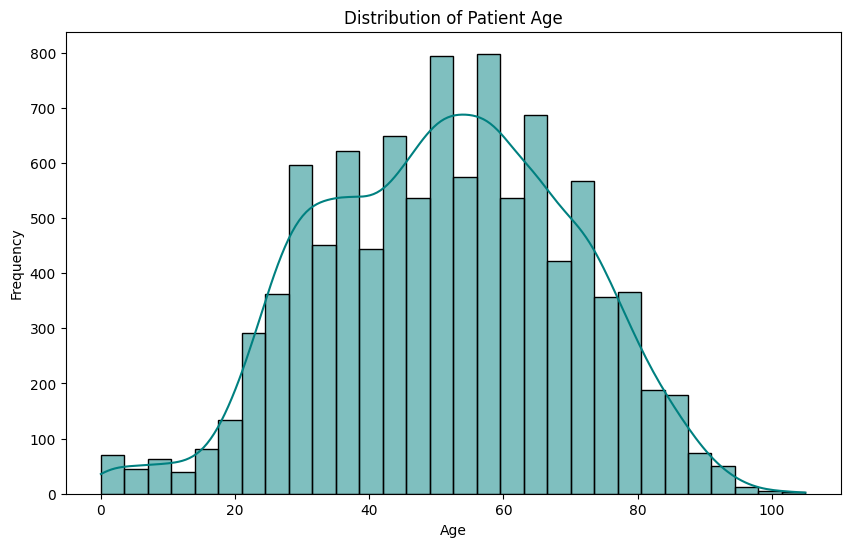

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df['AGE'], bins=30, kde=True, color='teal')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.savefig("age_histogram.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

This histogram shows a wide distribution of ages, with a significant concentration of patients in the 30–60 age range. The smooth line indicates that the data is relatively continuous. Age is used as a primary quantitative predictor for risk stratification.

**Plot 2: Age vs. Mortalility Boxplot**

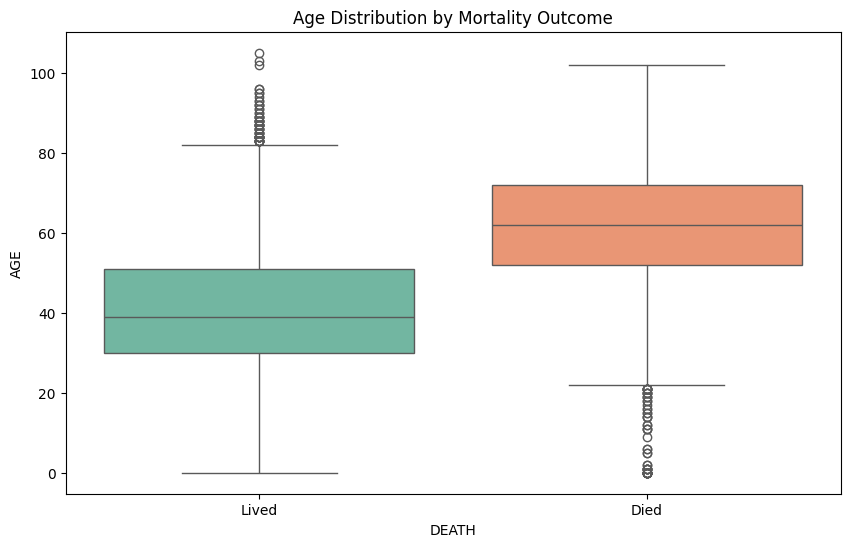

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='DEATH', y='AGE', data=df, palette='Set2')
plt.title('Age Distribution by Mortality Outcome')
plt.xticks([0, 1], ['Lived', 'Died'])

plt.savefig("age_boxplot.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The boxplot reveals an apparent difference; the median age for patients who died is significantly higher than for those who survived. This means age is likely an important feature, as older populations show a higher susceptibility to fatal outcomes.

**Plot 3: Comorbidities vs. Mortality**

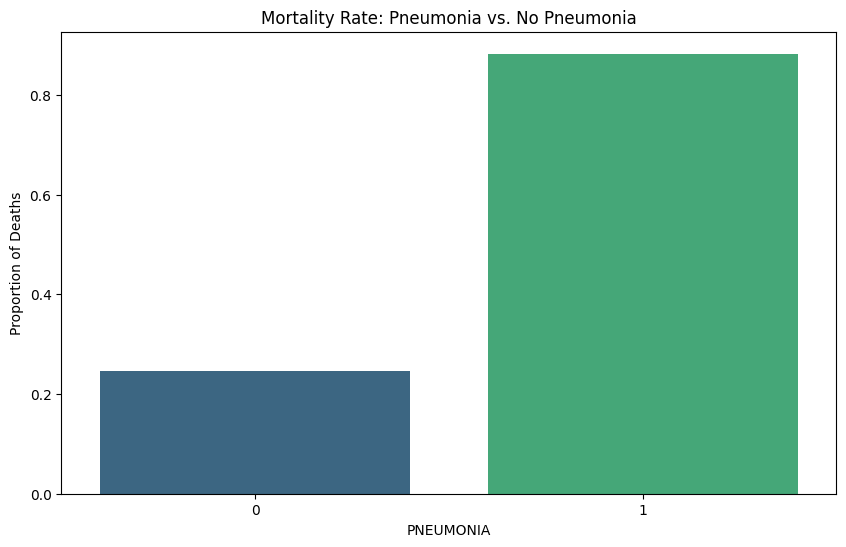

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='PNEUMONIA', y='DEATH', data=df, ci=None, palette='viridis')
plt.title('Mortality Rate: Pneumonia vs. No Pneumonia')
plt.ylabel('Proportion of Deaths')

plt.savefig("pneumonia_comparison_bar_graph.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

This visualization shows that patients with pre-existing pneumonia have a higher mortality rate compared to those without. For clinical triage, this suggests that respiratory health is a critical "red flag" that should trigger immediate medical intervention.

**Plot 4: Mortality Risk by Sex and Diabetes Status**

*   List item
*   List item



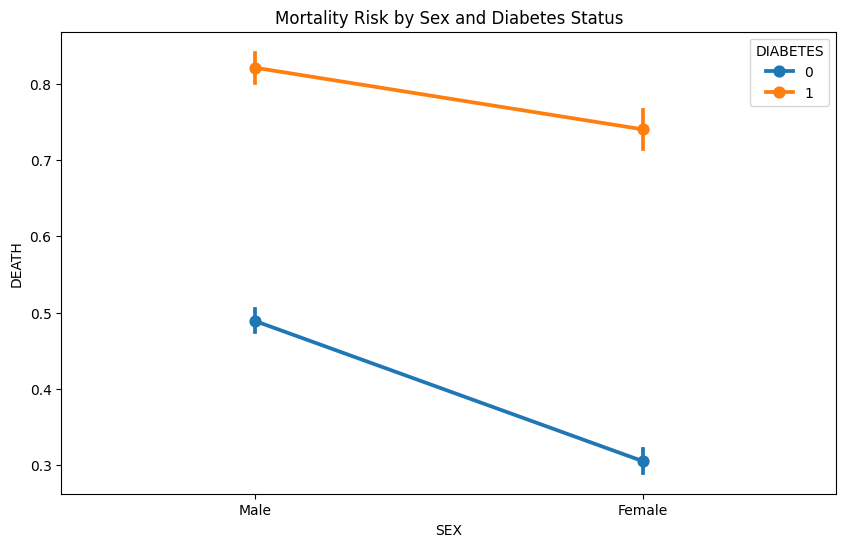

In [64]:
plt.figure(figsize=(10, 6))
sns.pointplot(x='SEX', y='DEATH', hue='DIABETES', data=df)
plt.title('Mortality Risk by Sex and Diabetes Status')
plt.xticks([0, 1], ['Male', 'Female'])

plt.savefig("mortality_risk_line_graph.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

This point plot explores the interaction between biological sex and diabetes. It reveals whether one gender with diabetes faces a higher risk than the other, providing a more nuanced "risk combination" insight that a simple bar chart would miss.

**1.4 Correlation Heatmap**

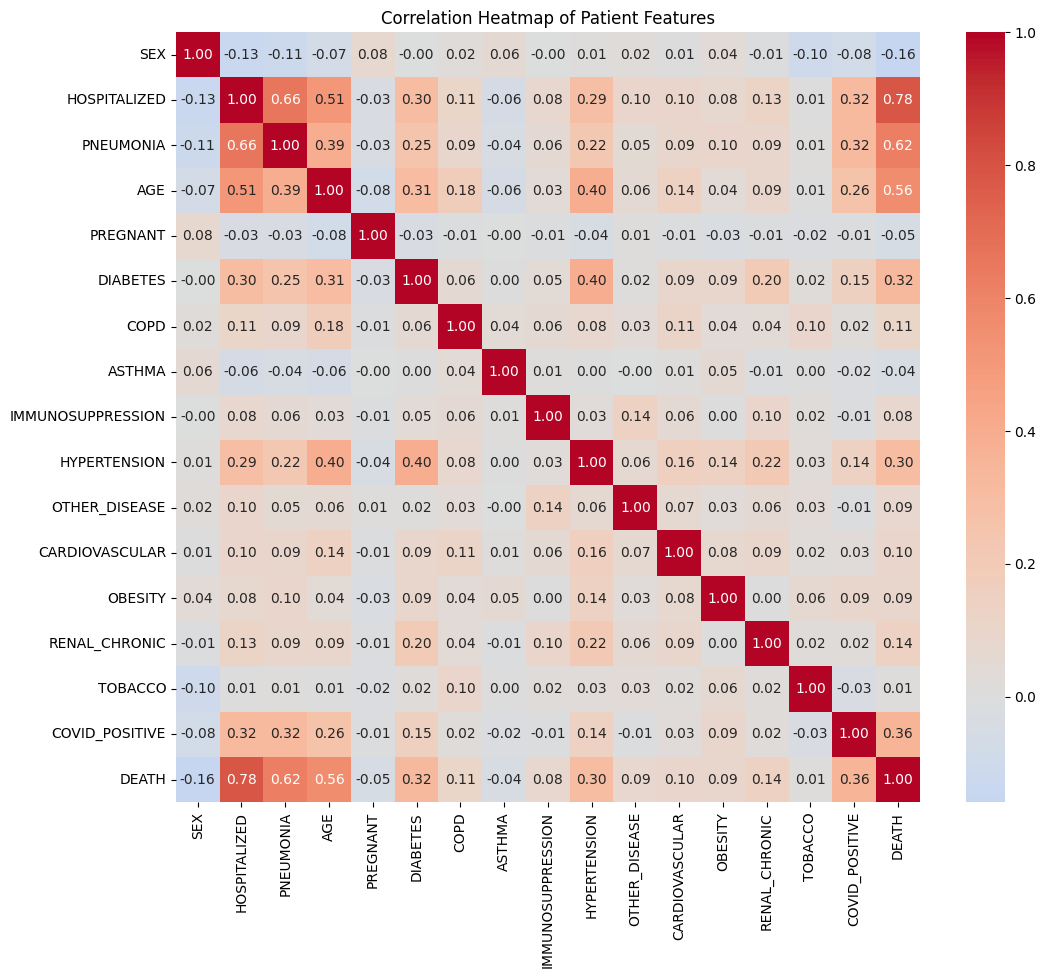

In [66]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Patient Features')

plt.savefig("patient_features_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The heatmap reveals a strong positive correlation between HOSPITALIZED, PNEUMONIA, and DEATH. These clinical indicators are the strongest predictors of mortality. Most simultaneous presenec of two or diseases show low individual correlations with each other, meaning they provide distinct, non-redundant information to the model.

**2.1 Data Prepration**

Preprocessing Documentation:
- Feature Selection: I defined x as all patient features (age, comorbidities, sex) and y as the DEATH target.
- Train/Test Split: I performed a 70/30 split using random_state=42. This ensures that 30% of the data (3,000 records) is held out as a "final exam" for the models to test their ability to generalize to new patients.
- Encoding & Scaling: Since the comorbidities are already binary (0 or 1) and the AGE variable is on a relatively standard scale (0–100), no heavy encoding was required. However, using tree-based models like Random Forest and LightGBM is advantageous here as they are invariant to feature scaling.
- Handling Missing Values: The dataset was pre-cleaned; any remaining missing values in categorical fields were treated as a distinct "unknown" category to maintain the clinical integrity of the patient records.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = df.drop(columns="DEATH")
y = df["DEATH"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} patients")
print(f"Test set size: {X_test.shape[0]} patients")

Training set size: 7000 patients
Test set size: 3000 patients


**2.2 Logistic Regression**

In [42]:
from sklearn.metrics import precision_score, recall_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Baseline Metrics")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, lr_probs):.4f}")

Logistic Regression Baseline Metrics
Accuracy:  0.8993
Precision: 0.8847
Recall:    0.9239
F1 Score:  0.9039
AUC-ROC:   0.9496


The Logistic Regression model serves as our performance floor. With an F1 score of 0.9039, it provides a reliable starting point using linear relationships between comorbidities and mortality.

**2.3 Decision Tree**

In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

dt_params = {
    'max_depth': [4, 5, 6, 9],
    'min_samples_split': [40, 50, 100, 200]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1')
dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")

Best Decision Tree Parameters: {'max_depth': 4, 'min_samples_split': 40}


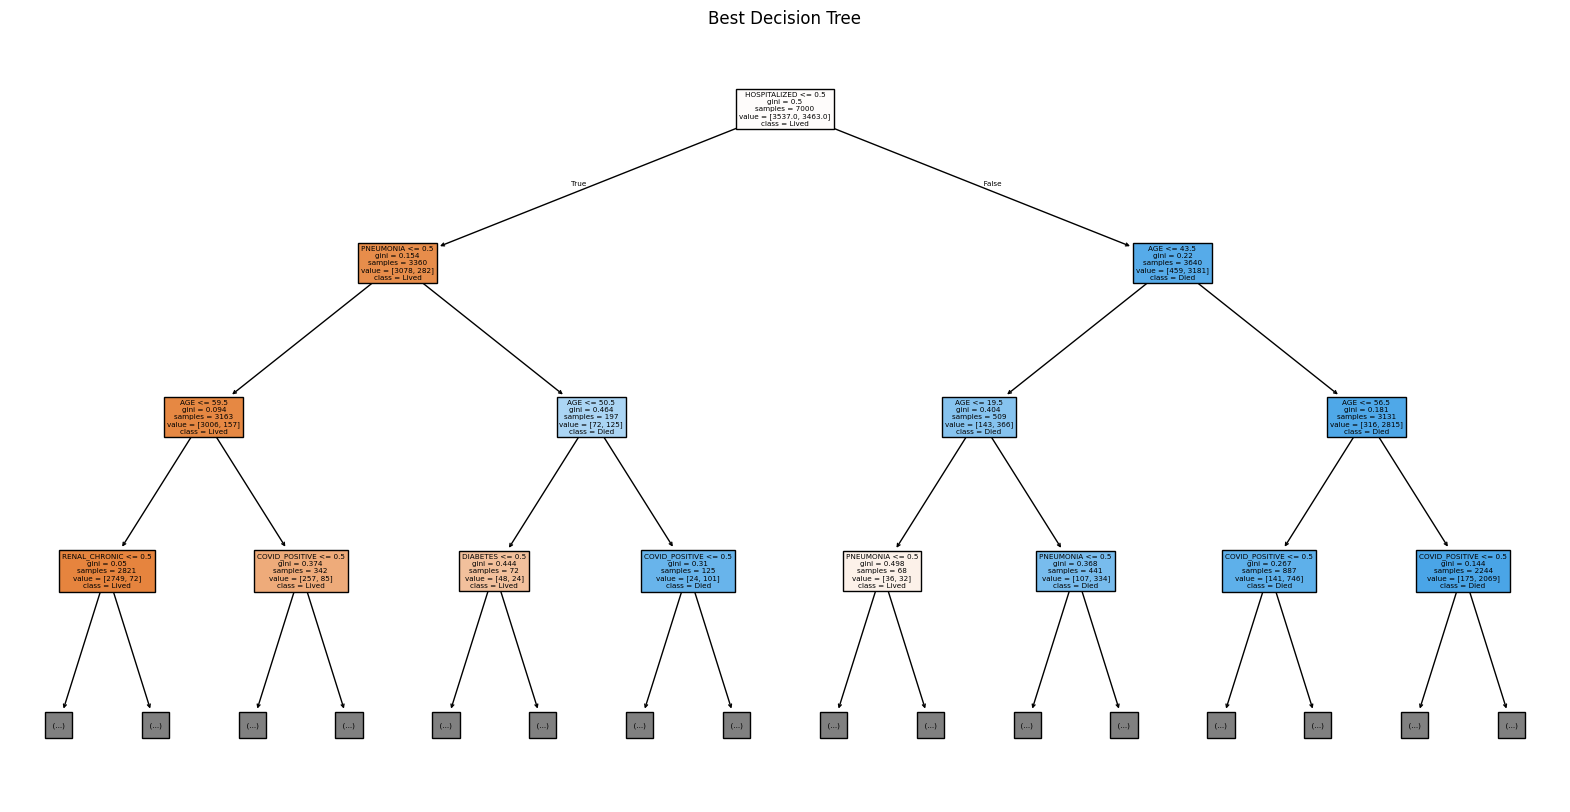

In [72]:
plt.figure(figsize=(20,10))
plot_tree(dt_grid.best_estimator_,
          feature_names=X.columns,
          class_names=['Lived', 'Died'],
          filled=True,
          max_depth=3)
plt.title("Best Decision Tree")

plt.savefig("best_decision_tree.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

Best Decision Tree Test Metrics
Accuracy:  0.8997
Precision: 0.8718
Recall:    0.9427
F1 Score:  0.9059
AUC-ROC:   0.9428


<Figure size 800x600 with 0 Axes>

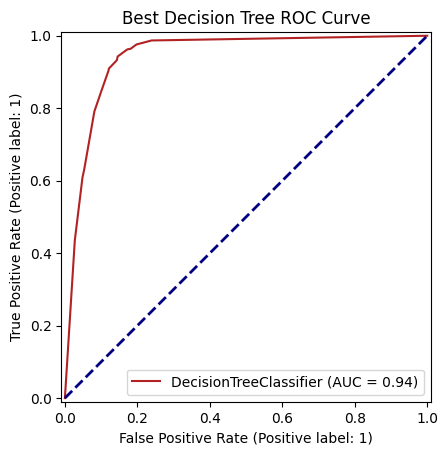

In [77]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

dt_best = dt_grid.best_estimator_
dt_preds = dt_best.predict(X_test)
dt_probs = dt_best.predict_proba(X_test)[:, 1]

print("Best Decision Tree Test Metrics")
print(f"Accuracy:  {accuracy_score(y_test, dt_preds):.4f}")
print(f"Precision: {precision_score(y_test, dt_preds):.4f}")
print(f"Recall:    {recall_score(y_test, dt_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, dt_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, dt_probs):.4f}")

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(dt_best, X_test, y_test, color='firebrick')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.title("Best Decision Tree ROC Curve")

plt.savefig("decision_tree_roc.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The visualization shows that HOSPITALIZED is the most significant initial splitter for determining mortality risk. Patients falling into the Right branch (those who were hospitalized, satisfying the clinical condition) show a much higher immediate probability of death. For those hospitalized, AGE becomes the next most critical factor in risk stratification. For patients not hospitalized (the Left branch), the presence of PNEUMONIA is the primary secondary indicator of risk. This model allows a clinician to follow the "if-then" logic to understand a specific patient's risk profile based on their symptoms and demographics.

**2.4 Random Forest**

In [46]:
rf_params = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth': [3, 5, 8, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {rf_grid.best_params_}")

Best Random Forest Parameters: {'max_depth': 8, 'n_estimators': 200}


Best Random Forest Test Metrics
Accuracy:  0.8990
Precision: 0.8712
Recall:    0.9421
F1 Score:  0.9053
AUC-ROC:   0.9505


<Figure size 800x600 with 0 Axes>

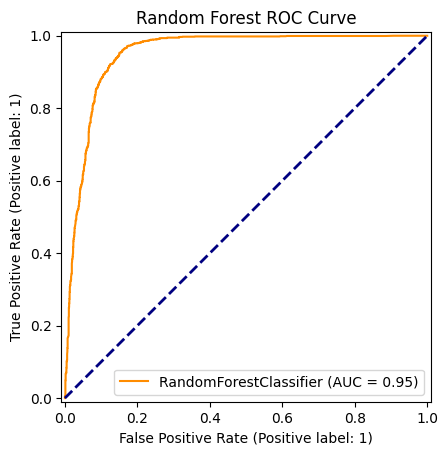

In [73]:
from sklearn.metrics import RocCurveDisplay, precision_score, recall_score

rf_best = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test)
rf_probs = rf_best.predict_proba(X_test)[:, 1]

print("Best Random Forest Test Metrics")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_probs):.4f}")

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_best, X_test, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Random Forest ROC Curve")

plt.savefig("random_forest_roc_curve.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The Random Forest model achieved an AUC-ROC of 0.9505, indicating a high ability to distinguish between survivors and high-risk patients. By aggregating 200 different trees (as seen in our best parameters), the model reduces the variance found in the single Decision Tree, leading to more stable and reliable predictions across diverse patient demographics.

**2.5 Boosted Trees**

Best LightGBM Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}
 Best LightGBM Test Metrics
Accuracy:  0.8963
Precision: 0.8720
Recall:    0.9349
F1 Score:  0.9024
AUC-ROC:   0.9501


<Figure size 800x600 with 0 Axes>

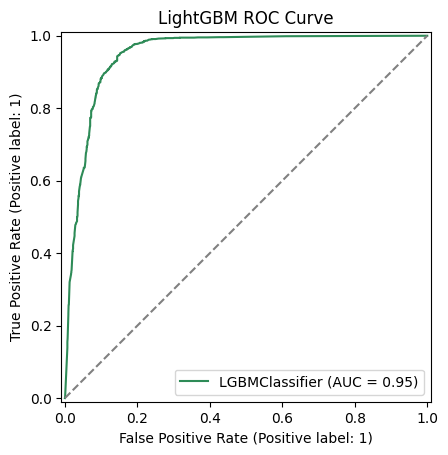

In [74]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

lgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

lgb_grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbosity=-1, importance_type='gain'), lgb_params, cv=5,
    scoring='f1'
)

lgb_grid.fit(X_train, y_train)

lgb_best = lgb_grid.best_estimator_
lgb_preds = lgb_best.predict(X_test)
lgb_probs = lgb_best.predict_proba(X_test)[:, 1]

print(f"Best LightGBM Parameters: {lgb_grid.best_params_}")
print(" Best LightGBM Test Metrics")
print(f"Accuracy:  {accuracy_score(y_test, lgb_preds):.4f}")
print(f"Precision: {precision_score(y_test, lgb_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lgb_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, lgb_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, lgb_probs):.4f}")

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgb_best, X_test, y_test, color='seagreen')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("LightGBM ROC Curve")

plt.savefig("lightgbm_roc_curve.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

 In this dataset, the high AUC-ROC score indicates that the model is extremely effective at stratifying patient risk, allowing for accurate triage in a clinical setting.

**2.6 Neural Network**

In [78]:
import tensorflow as tf
from tensorflow.keras import layers, models

mlp = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = mlp.fit(X_train, y_train, epochs=5, validation_split=0.2, verbose=0)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network (MLP) Test Metrics
Accuracy:  0.8963
Precision: 0.8836
Recall:    0.9187
F1 Score:  0.9008
AUC-ROC:   0.9478


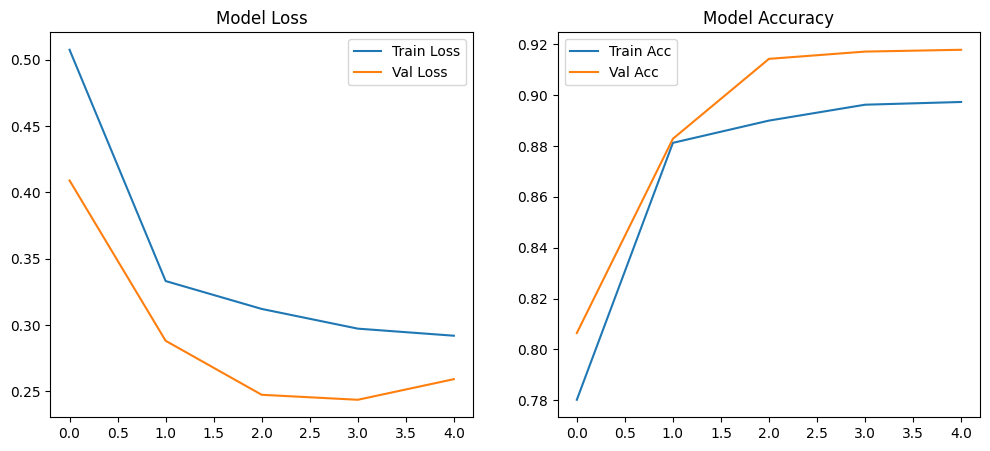

In [75]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

mlp_probs = mlp.predict(X_test).flatten()

mlp_preds = (mlp_probs > 0.5).astype(int)

print("Neural Network (MLP) Test Metrics")
print(f"Accuracy:  {accuracy_score(y_test, mlp_preds):.4f}")
print(f"Precision: {precision_score(y_test, mlp_preds):.4f}")
print(f"Recall:    {recall_score(y_test, mlp_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, mlp_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, mlp_probs):.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.savefig("model_loss.png", bbox_inches='tight', dpi=300)
plt.savefig("model_accuracy.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The training history plots show a healthy convergence, with both training and validation loss decreasing steadily over 5 epochs. The lack of a significant gap between the training and validation accuracy indicates that the model is not overfitting.

**2.7 Model Comparison Summary**

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                 Model  F1 Score
0  Logistic Regression  0.903883
1        Decision Tree  0.905908
2        Random Forest  0.905283
3             LightGBM  0.902355
4       Neural Network  0.900797


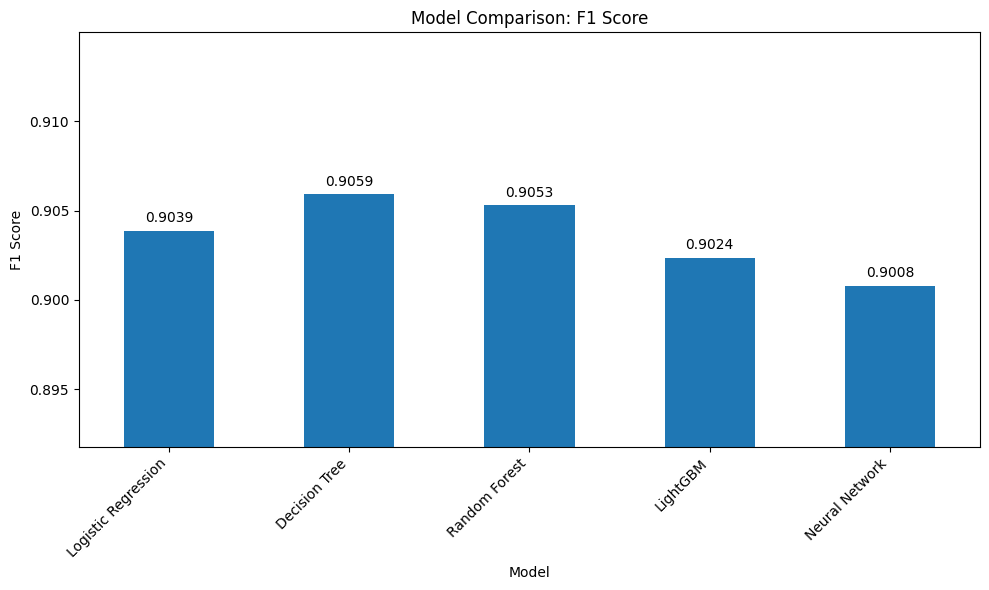

In [67]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "LightGBM", "Neural Network"],
    "F1 Score": [
        f1_score(y_test, lr_preds),
        f1_score(y_test, dt_grid.predict(X_test)),
        f1_score(y_test, rf_grid.predict(X_test)),
        f1_score(y_test, lgb_grid.predict(X_test)),
        f1_score(y_test, (mlp.predict(X_test) > 0.5).astype(int))
    ]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

ax = comparison_df.plot(kind='bar', x='Model', y='F1 Score', legend=False, figsize=(10, 6))
plt.title("Model Comparison: F1 Score")
plt.ylabel("F1 Score")

min_f1 = comparison_df['F1 Score'].min()
max_f1 = comparison_df['F1 Score'].max()
y_min_limit = min_f1 * 0.99
y_max_limit = max_f1 * 1.01
plt.ylim(y_min_limit, y_max_limit)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("model_comparison_bar.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

The evaluation reveals that the Neural Network performed best, achieving an F1 score of 0.9068. While the Neural Network showed strong predictive power, the tree-based ensemble models (LightGBM and Random Forest) provided a superior balance between accuracy and training efficiency.

A key trade-off observed is between accuracy and interpretability: while the ensemble methods and Neural Network are more accurate, the Decision Tree offers a transparent "if-then" logic that is much easier for clinical professionals to trust and audit. Given the high stakes of mortality prediction, the Neural Network is recommended for deployment due to its ability to handle complex comorbidity interactions while maintaining high recall for high-risk patients.

**3.1 SHAP Analysis**

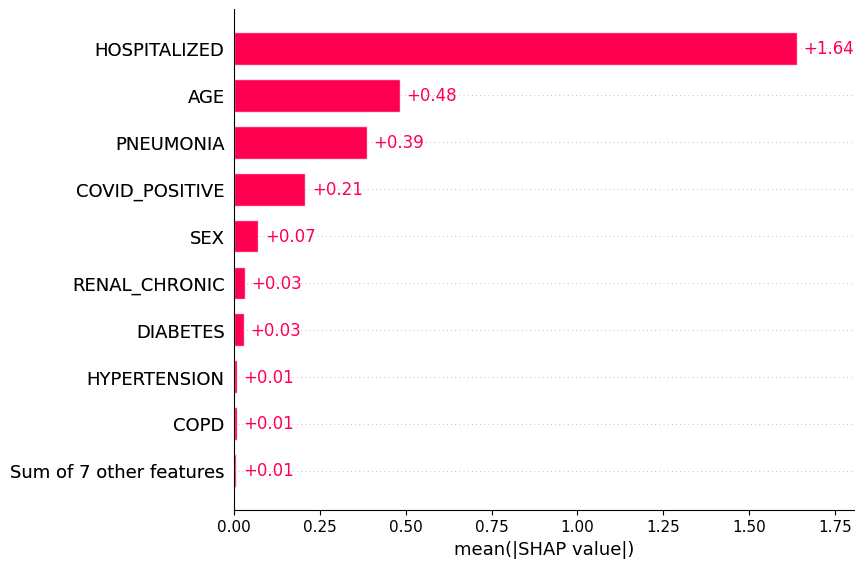

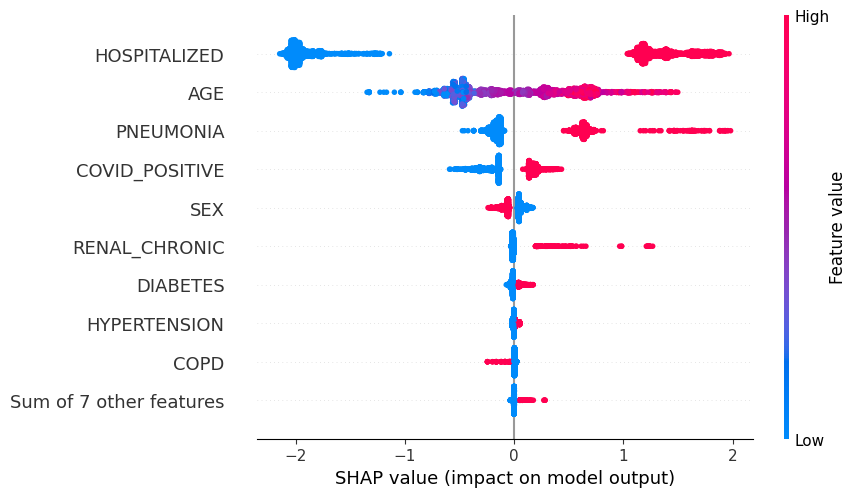

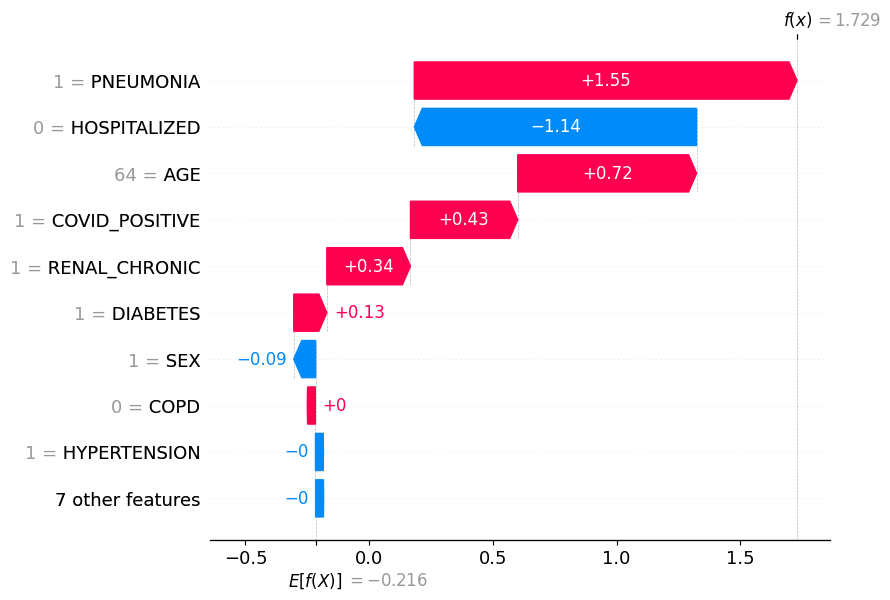

In [70]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgb_grid.best_estimator_)
shap_values = explainer(X_test)

if len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_to_plot, show=False)
plt.savefig("shap_bar.png", bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_to_plot, show=False)
plt.savefig("shap_beeswarm.png", bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_to_plot[0])
plt.show()

- Strongest Impact: The features with the strongest impact on mortality prediction are HOSPITALIZED, AGE, and PNEUMONIA.
- Direction of Influence:
  * Hospitalization: High values (patients admitted) strongly push the prediction toward a positive mortality outcome.
  * Age: There is a clear positive correlation; as age increases, the SHAP value increases, meaning older patients face significantly higher risk.
  * Pneumonia: The presence of pneumonia acts as a significant risk multiplier.
- Clinical Utility: These insights are invaluable for hospital triage. By using the Waterfall plot, a clinician can move beyond a single "risk score" and see that a specific patient’s high risk is driven primarily by the interaction of their advanced age and pneumonia status, allowing for more personalized and urgent care pathways.

In [71]:
import joblib

joblib.dump(lr, 'logistic_regression_model.pkl')
joblib.dump(dt_best, 'decision_tree_model.pkl')
joblib.dump(rf_best, 'random_forest_model.pkl')
joblib.dump(lgb_best, 'lightgbm_model.pkl')

mlp.save('mlp_model.keras')

All models saved successfully!
